In [421]:
import pandas as pd
df1 = pd.read_csv('cars.csv')

In [422]:
df1

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,0,2016,Honda,Honda Brio S MT,Brio,425000.0,9680.0,Petrol,Mumbai,7,5.0
1,1,2012,Nissan,Nissan Sunny XV Diesel,Sunny,325000.0,119120.0,Diesel,Mumbai,11,9.0
2,2,2017,Toyota,Toyota Fortuner 2.8 4x2 MT [2016-2020],Fortuner,2650000.0,64593.0,Diesel,Thane,1,4.0
3,3,2017,Mercedes-Benz,Mercedes-Benz E-Class E 220d Expression [2019-...,E-Class,4195000.0,25000.0,Diesel,Mumbai,2,4.0
4,4,2012,Hyundai,Hyundai Verna Fluidic 1.6 CRDi SX,Verna,475000.0,23800.0,Diesel,Mumbai,14,9.0
5,5,2012,Hyundai,Hyundai i20 Sportz 1.2 BS-IV,i20,335000.0,45000.0,Petrol,Mumbai,14,9.0
6,6,2019,Toyota,Toyota Glanza V,Glanza,750000.0,19500.0,Petrol,Mumbai,1,2.0
7,7,2018,Mercedes-Benz,Mercedes-Benz GLE 250 d,GLE,5500000.0,32000.0,Diesel,Mumbai,2,3.0
8,8,2017,Hyundai,Hyundai Grand i10 Sportz (O) AT 1.2 Kappa VTVT...,Grand,565000.0,44329.0,Petrol,Mumbai,14,4.0
9,9,2015,Maruti Suzuki,Maruti Suzuki Swift Dzire ZXI,Swift,510000.0,48286.0,Petrol,Mumbai,32,6.0


In [424]:
from sklearn import preprocessing

le=preprocessing.LabelEncoder()

df2=df1

df2.brand = le.fit_transform(df2.brand)
df2.full_model_name = le.fit_transform(df2.full_model_name)

df2.model_name = le.fit_transform(df2.model_name)

df2.fuel_type = le.fit_transform(df2.fuel_type)

df2.city = le.fit_transform(df2.city)

df2.brand = le.fit_transform(df2.brand)

df2

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,0,2016,7,131,28,425000.0,9680.0,3,9,7,5.0
1,1,2012,23,570,129,325000.0,119120.0,1,9,11,9.0
2,2,2017,28,676,69,2650000.0,64593.0,1,14,1,4.0
3,3,2017,21,526,51,4195000.0,25000.0,1,9,2,4.0
4,4,2012,8,259,144,475000.0,23800.0,1,9,14,9.0
5,5,2012,8,291,167,335000.0,45000.0,3,9,14,9.0
6,6,2019,28,681,80,750000.0,19500.0,3,9,1,2.0
7,7,2018,21,547,76,5500000.0,32000.0,1,9,2,3.0
8,8,2017,8,236,81,565000.0,44329.0,3,9,14,4.0
9,9,2015,20,471,131,510000.0,48286.0,3,9,32,6.0


In [425]:
print(df2.var())
print(df2.var().min())

df3=df2.drop('city',axis="columns")
df3

Id                         2.481125e+05
year                       1.028808e+01
brand                      8.461353e+01
full_model_name            4.718125e+04
model_name                 2.392481e+03
price                      2.794440e+12
distance_travelled(kms)    2.000374e+09
fuel_type                  1.017958e+00
city                       1.874791e+01
brand_rank                 1.677315e+02
car_age                    1.028808e+01
dtype: float64
1.0179582366589184


,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,brand_rank,car_age
0,0,2016,7,131,28,425000.0,9680.0,3,7,5.0
1,1,2012,23,570,129,325000.0,119120.0,1,11,9.0
2,2,2017,28,676,69,2650000.0,64593.0,1,1,4.0
3,3,2017,21,526,51,4195000.0,25000.0,1,2,4.0
4,4,2012,8,259,144,475000.0,23800.0,1,14,9.0
5,5,2012,8,291,167,335000.0,45000.0,3,14,9.0
6,6,2019,28,681,80,750000.0,19500.0,3,1,2.0
7,7,2018,21,547,76,5500000.0,32000.0,1,2,3.0
8,8,2017,8,236,81,565000.0,44329.0,3,14,4.0
9,9,2015,20,471,131,510000.0,48286.0,3,32,6.0


In [429]:
X=df3.drop('price',axis="columns")
Y=df3[['price']]
print(type(Y))
print(type(X))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [431]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [437]:
from sklearn import linear_model

model=linear_model.LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [439]:
y_pred=model.predict(X_test)
print(type(y_pred))
print((type(y_test)))
y_pred_df=pd.DataFrame({'res':y_pred[:,0]})

from sklearn.metrics import mean_absolute_percentage_error

print(mean_absolute_percentage_error(y_test,y_pred_df))

<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>
1.4180120893252923


In [48]:
from sklearn.metrics import mean_squared_error, r2_score
print(r2_score(y_test,y_pred_df))

0.2616198234446435


## RANDOM FOREST

In [51]:

from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=500,max_features='log2', max_depth=50,random_state=42,max_samples=0.99)
rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('..........',mse)
print(r2)

/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


.......... 972722625803.7826
0.7102417042365274


/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


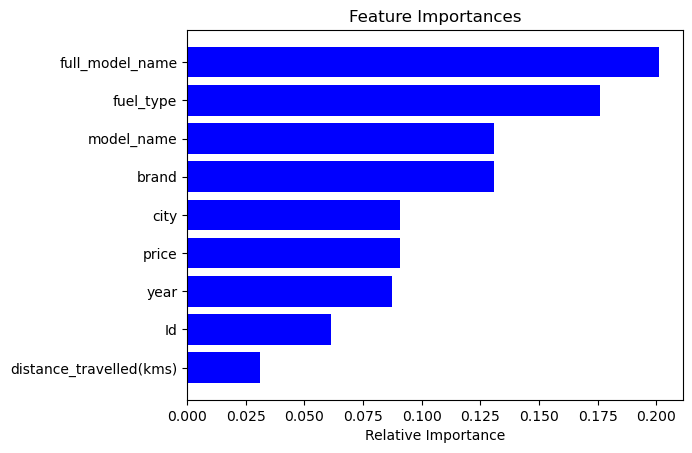

In [53]:
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=500,max_features='log2', max_depth=50,random_state=42,max_samples=0.99)
rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
features = df2.columns
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[-9:]  # top 10 features
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [77]:
#df2.drop("Id",axis="columns",inplace=True)
#df3.drop("city",axis="columns",inplace=True)

#df3.drop("distance_travelled(kms)",axis="columns",inplace=True)
#df3.drop("year",axis="columns",inplace=True)
X=df3.drop('price',axis="columns")
Y=df3[['price']]
print(type(Y))
print(type(X))
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=500,max_features='log2', max_depth=50,random_state=42,max_samples=0.99)
rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse",mse)
print(mean_absolute_percentage_error(y_test,y_pred_df))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


mse 1023532758487.1362
<function r2_score at 0x7f0802b91c60>
0.8813755006752688


## PCA

In [383]:
print(df2)

#df2.drop('Id',inplace=True,axis=1)
df2.drop('city',inplace=True,axis=1)


      year  brand  full_model_name  model_name       price  fuel_type  \
0     2016      7              131          28    425000.0          3   
1     2012     23              570         129    325000.0          1   
2     2017     28              676          69   2650000.0          1   
3     2017     21              526          51   4195000.0          1   
4     2012      8              259         144    475000.0          1   
5     2012      8              291         167    335000.0          3   
6     2019     28              681          80    750000.0          3   
7     2018     21              547          76   5500000.0          1   
8     2017      8              236          81    565000.0          3   
9     2015     20              471         131    510000.0          3   
10    2015      8              273         161    465000.0          3   
11    2016     28              696          87   1485000.0          1   
12    2017     20              403          25    6

KeyError: "['city'] not found in axis"

In [389]:
X=df2.drop('price',axis="columns")
y=df2[['price']]


In [391]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state=42)
y_train=y_train.reset_index(drop=True)
y_test=y_test.reset_index(drop=True)
X_train=X_train.reset_index(drop=True)
X_test=X_test.reset_index(drop=True)


In [393]:
#Standardization

from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [395]:
# lets determine the Value of N-Components
from sklearn.decomposition import PCA

# Lets create the PCA Model
pca = PCA(n_components = None)
x_train_pca = pca.fit_transform(X_train_sc)
x_test_pca = pca.transform(X_test_sc)

# This result the variance explained by the number of components taken into account
pca.explained_variance_ratio_.cumsum()  # To find which one is the optimal Compoment 

array([0.3112871 , 0.59239538, 0.75482899, 0.88972849, 0.99864145,
       1.        , 1.        ])

In [401]:
df_x_train=pd.DataFrame({'x_train_pca0':x_train_pca[:,0],'x_train_pca1':x_train_pca[:,1]})
pd.set_option('display.max_rows', None)
y_train['price']=y_train['price'].astype(float)
df_x_train['x_train_pca0']=df_x_train['x_train_pca0'].astype(float)
df_x_train['x_train_pca1']=df_x_train['x_train_pca1'].astype(float)
y_train=y_train.reset_index(drop=True)
df_x_train=df_x_train.reset_index(drop=True)

df_x_y_train=pd.concat([df_x_train,Y_train],axis=1)
pd.set_option('display.max_rows', None)

print(df_x_train.shape)
print(y_train.shape)
print(df_x_y_train.shape)

df_x_test=pd.DataFrame({'x_train_pca0':x_test_pca[:,0],'x_train_pca1':x_test_pca[:,1]})


y_test['price']=y_test['price'].astype(float)
df_x_test['x_train_pca0']=df_x_test['x_train_pca0'].astype(float)
df_x_test['x_train_pca1']=df_x_test['x_train_pca1'].astype(float)
y_test=y_test.reset_index(drop=True)
df_x_test=df_x_test.reset_index(drop=True)

df_x_y_test=pd.concat([df_x_test,y_test],axis=1)
pd.set_option('display.max_rows', None)

df=df_x_y_test

print(df_x_test.shape)
print(y_test.shape)
print(df_x_y_test.shape)


(1380, 2)
(1380, 1)
(1380, 3)
(345, 2)
(345, 1)
(345, 3)


In [413]:
X=df.drop('price',axis="columns")
Y=df[['price']]
print(type(Y))
print(type(X))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [417]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

print(X_train.columns)
print(X_test.columns)

print(y_train.columns)

print(y_test.columns)



Index(['x_train_pca0', 'x_train_pca1'], dtype='object')
Index(['x_train_pca0', 'x_train_pca1'], dtype='object')
Index(['price'], dtype='object')
Index(['price'], dtype='object')


In [419]:
#from sklearn.model_selection import train_test_split


from sklearn import linear_model
pd.set_option('display.max_rows', None)

model_l=linear_model.LinearRegression()
print(y_train.price)
model_l.fit(X_train,y_train)
y_pred=model_l.predict(y_train)
 
from sklearn.metrics import mean_absolute_percentage_error

print(y_train)
#print(y_pred_df)

print('....',mean_absolute_percentage_error(y_test,y_pred))

66      1850000.0
229     1435000.0
7       2600000.0
140     1650000.0
324      600000.0
329      235000.0
302      800000.0
78       575000.0
147     4400000.0
94      1385000.0
258     2575000.0
60       625000.0
333      550000.0
239     1050000.0
132      925000.0
202      171000.0
152     1395000.0
17       400000.0
24       445000.0
238     1050000.0
145     1650000.0
209      365000.0
254      690000.0
288     3800000.0
139     1545000.0
304     4300000.0
179      390000.0
143     1000000.0
19      4500000.0
256      325000.0
79      2125000.0
108      580000.0
18       465000.0
116      625000.0
267    12300000.0
31      3300000.0
245      850000.0
278       80000.0
165      475000.0
250     1800000.0
126     4700000.0
282     1220000.0
59       335000.0
111      450000.0
197      180000.0
15      2700000.0
6        675000.0
244     1451000.0
222      690000.0
93      4800000.0
30       320000.0
22      4350000.0
327     1250000.0
303      370000.0
56       770000.0
272      2

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- price
Feature names seen at fit time, yet now missing:
- x_train_pca0
- x_train_pca1
